In [1]:
%load_ext autoreload
%autoreload 2

## Setup

In [2]:
import ulysses
import numpy as np
import matplotlib.pyplot as plt
import src.plot_style as ps
from src.etaB_1DME_sct import EtaB_1DME_sct
from src.etaB_1BE1F_sct import EtaB_1BE1F_sct, EtaB_1BE1F_custom
from src.scattering import scat_Ss, scat_St, washout_sct

from utils.directories import dir_params_A, dir_params_B, dir_params_C

In [3]:
# Select the 1DME model (1 RHN, Density Matrix Equation with flavor effects)
EtaB_1DME = ulysses.EtaB_1DME
EtaB_1BE = ulysses.EtaB_1BE1F
# Create model with scattering



In [4]:
# Create model instance
uls_1DME = EtaB_1DME()
uls_1BE = EtaB_1BE()
uls_1DME_sct = EtaB_1DME_sct()
uls_1BE_sct = EtaB_1BE1F_sct()

In [5]:
# TY's parameters from page 2 (Reference [2]: Granelli, Moffat, Petcov 2021)
# M3 = 5*M2 = 50*M1
uls_1DME.setParams(dir_params_A)
uls_1BE.setParams(dir_params_A)
uls_1DME_sct.setParams(dir_params_A)
uls_1BE_sct.setParams(dir_params_A)

## BAU: 1DME & 1B1EF

In [6]:
# Compute baryon asymmetry
eta1DME= uls_1DME.EtaB
eta1BE = uls_1BE.EtaB
eta1DME_sct = uls_1DME_sct.EtaB
eta1BE_sct = uls_1BE_sct.EtaB

-8.414223188282331e-05 1.4014512722049647e-05


In [7]:
print("Model point A:")
print(f"eta_B (1DME) = {eta1DME:.3e}")
print(f"eta_B (1BE) = {eta1BE:.3e}")
print(f"eta_B (1DME with scattering) = {eta1DME_sct:.3e}")
print(f"eta_B (1BE with scattering) = {eta1BE_sct:.3e}")

Model point A:
eta_B (1DME) = 2.849e-08
eta_B (1BE) = 1.203e-10
eta_B (1DME with scattering) = -1.879e-09
eta_B (1BE with scattering) = 4.663e-11


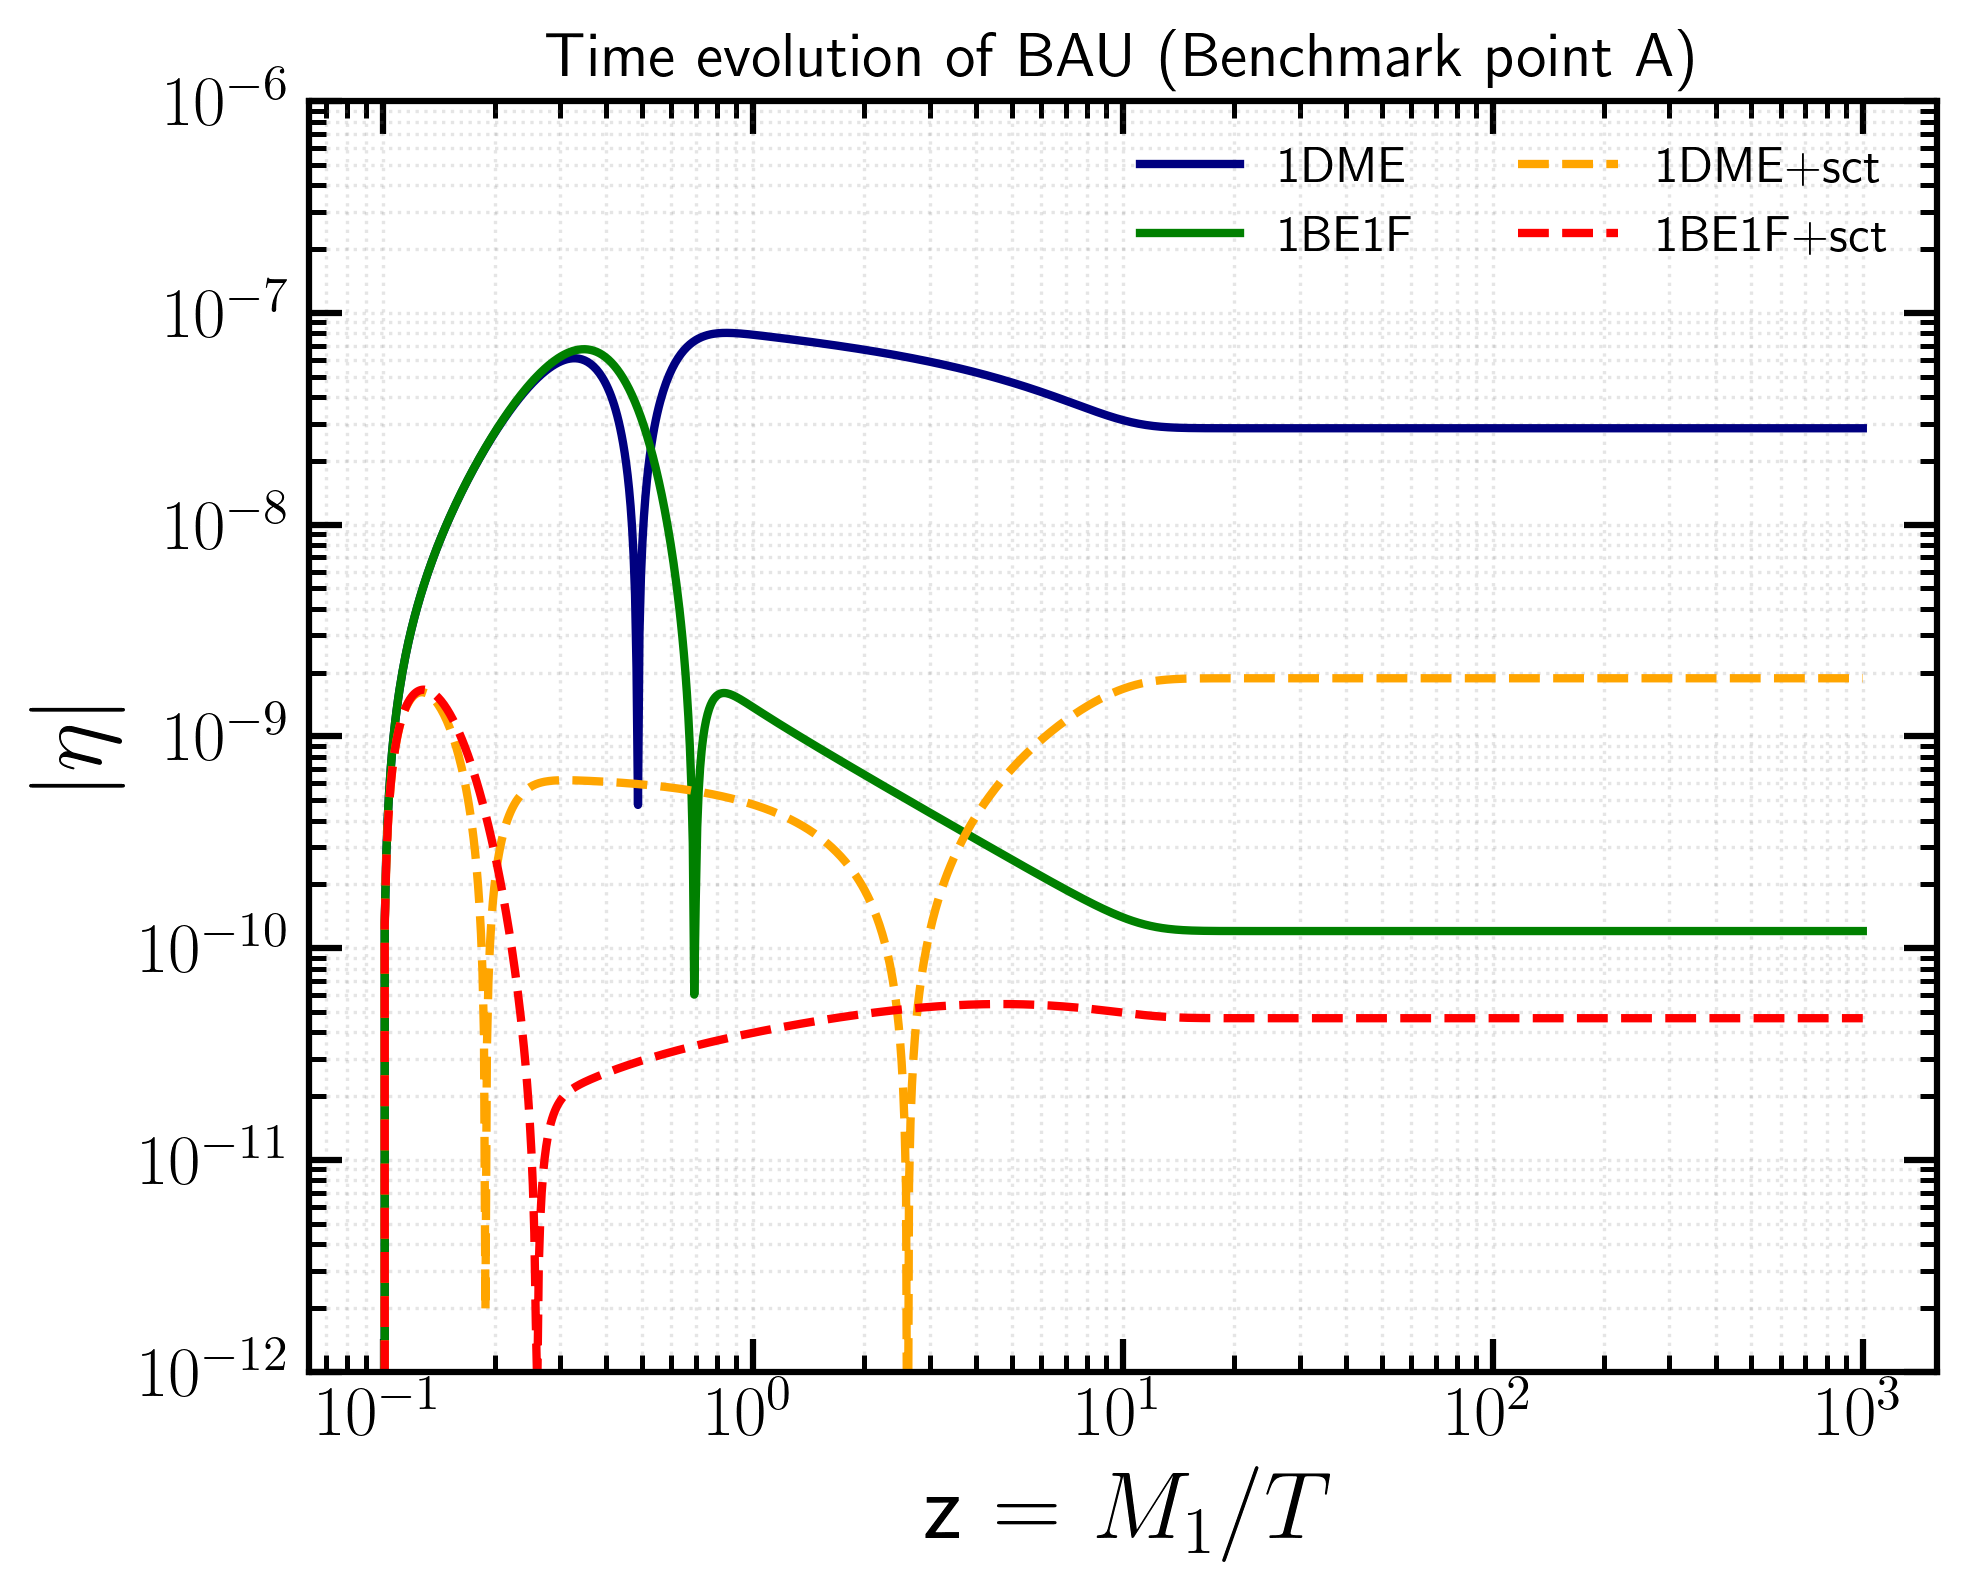

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300, facecolor="white")
z1DME   = uls_1DME.evolData[:, 0]
z1BE    = uls_1BE.evolData[:, 0]
z1DME_sct = uls_1DME_sct.evolData[:, 0]
z1BE_sct = uls_1BE_sct.evolData[:, 0]
eta1DME11 = uls_1DME.evolData[:, 4]
eta1BE11 = uls_1BE.evolData[:, 2]
eta1DME_sct11 = uls_1DME_sct.evolData[:, 4]
eta1BE_sct11 = uls_1BE_sct.evolData[:, 2]


plt.plot(z1DME, np.abs(eta1DME11), label="1DME", color='navy', lw=2)
plt.plot(z1BE, np.abs(eta1BE11), label="1BE1F", color='green', lw=2)
plt.plot(z1DME_sct, np.abs(eta1DME_sct11), label="1DME+sct", color='orange', lw=2, ls="--")
plt.plot(z1BE_sct, np.abs(eta1BE_sct11), label="1BE1F+sct", color='red', lw=2, ls="--")


ps.style_axes(ax, 
              xlog=True,
              ylog=True,
              xlabel="z = $M_1/T$", 
              ylabel="$|\eta|$", 
              ylim=(1e-12, 1e-6),
              title="Time evolution of BAU (Benchmark point A)")


ps.clean_legend(ax, loc="best", fontsize=12, ncol=2)
ax.grid(which="both", ls=":", color="gray", alpha=0.2)
plt.show()
fig.savefig("plots/etaB_evolution_A_degrees.png", bbox_inches="tight", dpi=300)

# Note: Numerical discrepancy with TY's results

## Issue
Our η values for Model Point A differ from TY's by a factor of ~3-5:
- **TY**: η_1DME = 2.84e-08, η_1DME+sct = -3.46e-09
- **Mine**: η_1DME = 3.54e-08, η_1DME+sct = 1.103e-08

Qualitative behavior (shape of curves, hierarchy between models) is correct.

## Possible causes
- NuFit 6.0+SK best fit values differ from what we used (tried θ₁₂=33.68°, θ₁₃=8.56°, θ₂₃=43.3°, δ=212° — didn't help)
- Mass squared splittings (Δm²₂₁, Δm²₃₁) might differ from ULYSSES defaults
- Majorana phases α₂₁, α₃₁: unclear if TY stored them in radians or degrees (the bug he mentions)
- Possible differences in ULYSSES version or internal constants

## Action
Discuss with TY at next meeting. Ask:
1. Which exact NuFit values did he use?
2. Are α₂₁, α₃₁ in radians or degrees for model point A?
3. Which ULYSSES version / any local modifications beyond scattering?

## Scattering approach: Modifying 1DEM & 1BE1F
- D1(k, z)  →  DS(k, z)            Decay → Decay + Scattering source

- W1(k, z)  →  scat(z) * W1(k, z)  Washout → Washout × scattering factor

## Asymmetry evolution

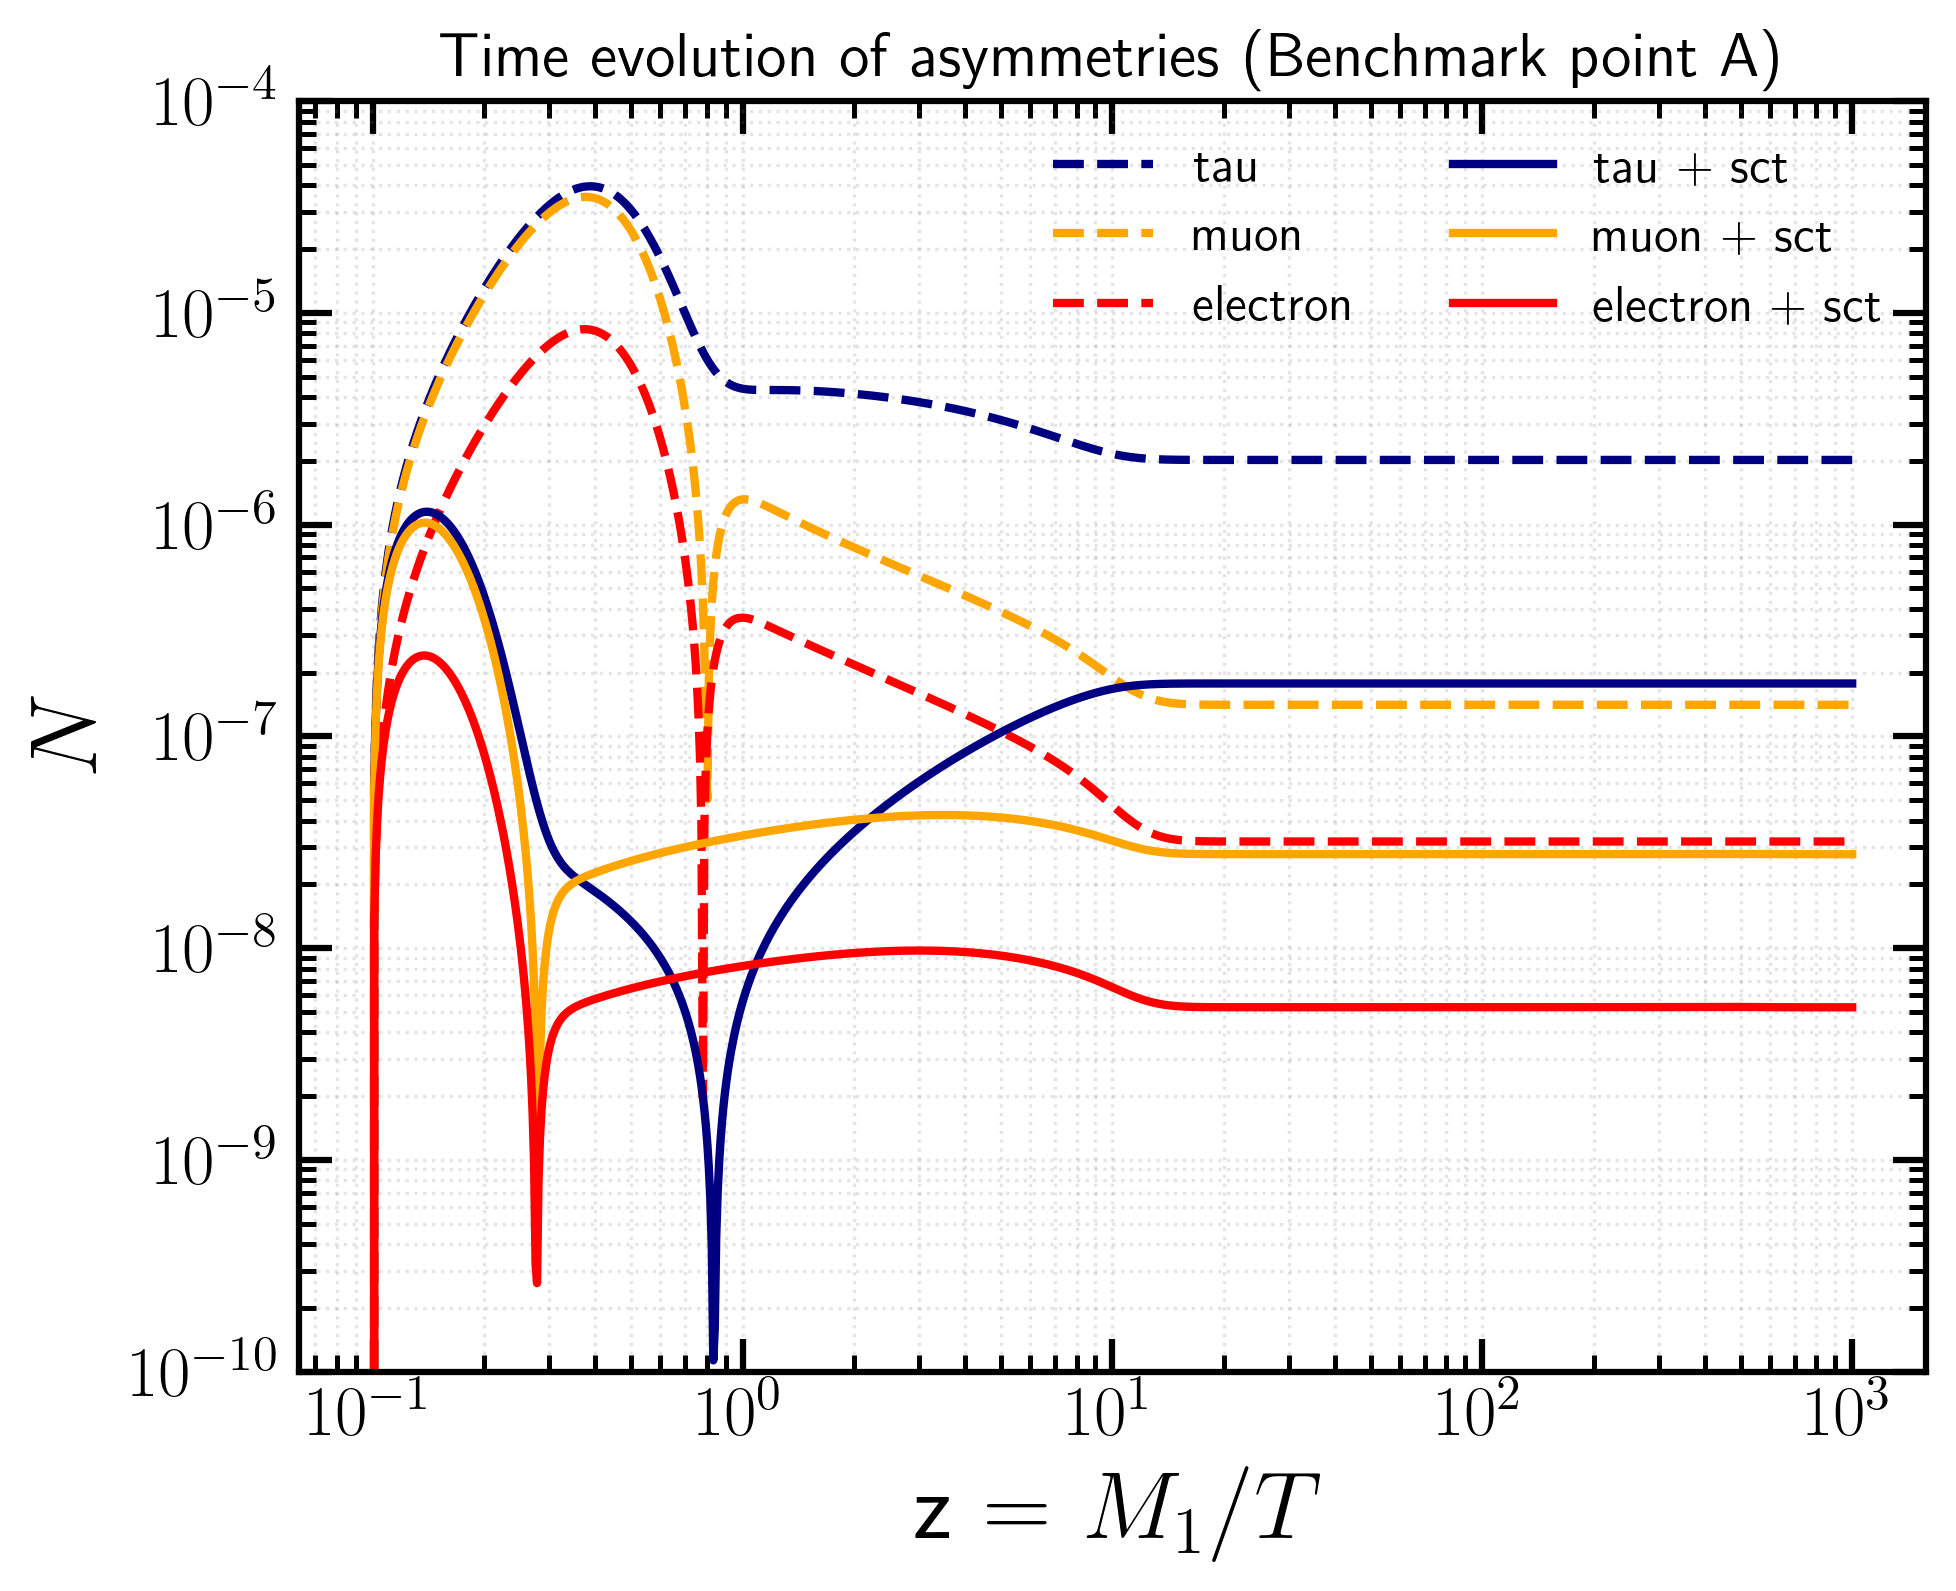

In [9]:
# Plot of time evolution of each flavor asymmetry

fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300, facecolor="white")
z     = uls_1DME.evolData[:, 0]
N_tt  = uls_1DME.evolData[:, 1]  # tau
N_mm  = uls_1DME.evolData[:, 2]  # muon
N_ee  = uls_1DME.evolData[:, 3]  # electron
# Including sct
z_sct     = uls_1DME_sct.evolData[:, 0]
N_tt_sct  = uls_1DME_sct.evolData[:, 1]  # tau
N_mm_sct  = uls_1DME_sct.evolData[:, 2]  # muon
N_ee_sct  = uls_1DME_sct.evolData[:, 3]  # electron

plt.plot(z, np.abs(N_tt), label="tau", color='navy', lw=2, ls="--")
plt.plot(z, np.abs(N_mm), label="muon", color='orange', lw=2, ls="--")
plt.plot(z, np.abs(N_ee), label="electron", color='red', lw=2, ls="--")
plt.plot(z_sct, np.abs(N_tt_sct), label="tau + sct", color='navy', lw=2, ls="-")
plt.plot(z_sct, np.abs(N_mm_sct), label="muon + sct", color='orange', lw=2, ls="-")
plt.plot(z_sct, np.abs(N_ee_sct), label="electron + sct", color='red', lw=2, ls="-")


ps.style_axes(ax, 
              xlog=True,
              ylog=True,
              xlabel="z = $M_1/T$", 
              ylabel="$N$", 
              ylim=(1e-10, 1e-4),
              title="Time evolution of asymmetries (Benchmark point A)")


ps.clean_legend(ax, loc="best", fontsize=12, ncol=2)
ax.grid(which="both", ls=":", color="gray", alpha=0.2)
plt.show()
fig.savefig("plots/Ni_evolution_A_degrees.png", bbox_inches="tight", dpi=300)

In [10]:


z_arr = np.logspace(-1, 3, 500)
k = np.real(uls_1DME.k1)
M1 = np.real(uls_1DME.DM[0, 0])
MH = uls_1DME.MH

D  = np.array([np.real(uls_1DME.D1(k, z)) for z in z_arr])
Ss = np.array([scat_Ss(k, z) for z in z_arr])
St = np.array([scat_St(k, z, M1, MH) for z in z_arr])
DS = D + Ss + St
W  = np.array([np.real(uls_1DME.W1(k, z)) for z in z_arr])

# For W+ΔW we need N1 at each z, but for this plot TY just shows
# the rates, so we can approximate N1 ~ N1eq
WdW = np.array([
    washout_sct(np.real(uls_1DME.W1(k, z)), np.real(uls_1DME.D1(k, z)),
                uls_1DME.N1Eq(z), uls_1DME.N1Eq(z), scat_Ss(k, z), scat_St(k, z, M1, MH))
    for z in z_arr
])

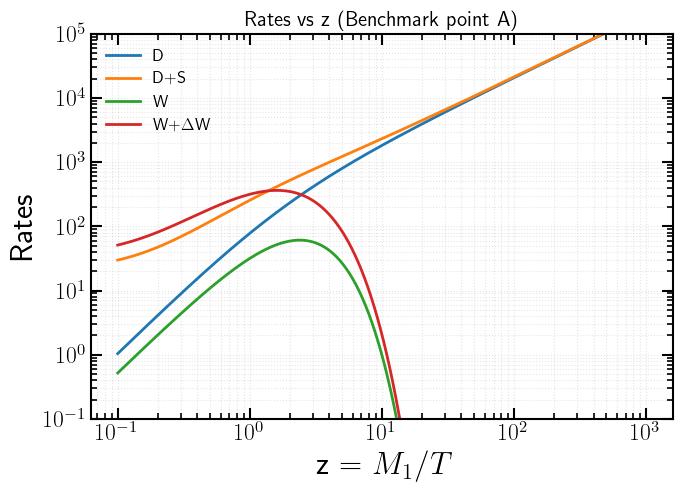

In [15]:
# Plotting the rates
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=100, facecolor="white")
ax.loglog(z_arr, D,   label="D",          color='tab:blue',   lw=2)
ax.loglog(z_arr, DS,  label="D+S",        color='tab:orange', lw=2)
ax.loglog(z_arr, W,   label="W",          color='tab:green',  lw=2)
ax.loglog(z_arr, WdW, label=r"W+$\Delta$W", color='tab:red', lw=2)
ps.style_axes(ax, 
              xlog=True,
              ylog=True,
              xlabel="z = $M_1/T$", 
              ylabel="Rates", 
              ylim=(1e-1, 1e5),
              title="Rates vs z (Benchmark point A)")
ps.clean_legend(ax, loc="best", fontsize=12)
ax.grid(which="both", ls=":", color="gray", alpha=0.2)
plt.show()
fig.savefig("plots/rates_A.png", bbox_inches="tight", dpi=300)

In [12]:
M1_values = np.linspace(9, 16, 50)  # log10(M1/GeV) from 1e12 to 1e16
eta_1DME     = []
eta_1DME_sct = []
eta_1BE      = []
eta_1BE_sct  = []

for M1 in M1_values:
    params = dir_params_A.copy()
    params["M1"] = M1
    params["M2"] = M1 + 1    # M2/M1 = 10
    params["M3"] = M1 + 2    # M3/M2 = 10

    uls_1 = ulysses.EtaB_1DME()
    uls_1.setParams(params)
    eta_1DME.append(uls_1.EtaB)

    uls_2 = EtaB_1DME_sct()
    uls_2.setParams(params)
    eta_1DME_sct.append(uls_2.EtaB)

    uls_3 = EtaB_1BE1F_custom()
    uls_3.setParams(params)
    eta_1BE.append(uls_3.EtaB)

    uls_4 = EtaB_1BE1F_sct()
    uls_4.setParams(params)
    eta_1BE_sct.append(uls_4.EtaB)



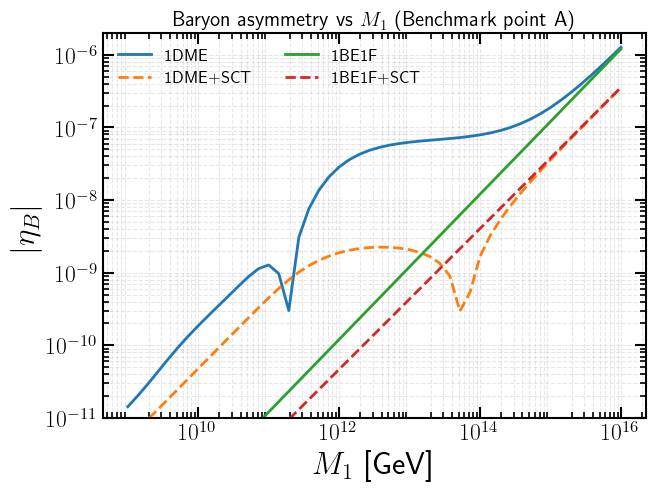

In [16]:
eta_1DME_plot     = np.array(eta_1DME)
eta_1DME_sct_plot = np.array(eta_1DME_sct)
eta_1BE_plot      = np.array(eta_1BE)
eta_1BE_sct_plot  = np.array(eta_1BE_sct)



fig, ax = plt.subplots(figsize=(7, 5), dpi=100, facecolor="white")
ax.plot(10**M1_values, np.abs(eta_1DME_plot),     label="1DME",      color='tab:blue',   lw=2)
ax.plot(10**M1_values, np.abs(eta_1DME_sct_plot), label="1DME+SCT",  color='tab:orange', lw=2, ls="--")
ax.plot(10**M1_values, np.abs(eta_1BE_plot),      label="1BE1F",     color='tab:green',  lw=2)
ax.plot(10**M1_values, np.abs(eta_1BE_sct_plot),  label="1BE1F+SCT", color='tab:red',    lw=2, ls="--")

ps.style_axes(ax, 
              xlog=True,
              ylog=True,
              xlabel="$M_1$ [GeV]", 
              ylabel="$|\eta_B|$", 
              ylim=(1e-11, 2e-6),
              title="Baryon asymmetry vs $M_1$ (Benchmark point A)")
ps.clean_legend(ax, loc="best", fontsize=12, ncol=2)
ax.grid(True, which="both", ls="--", alpha=0.3)
plt.show()
fig.savefig("plots/etaB_vs_M1_A.png", bbox_inches="tight", dpi=300)